# <span style="color:rgb(213,80,0)">ROZWIĄZYWANIE UKŁADÓW RÓWNAŃ LINIOWYCH</span>

## Metoda rozkładu QR

Aby zobrazować zaletę metody QR pod względem układów równań porównamy ją z eliminacją Gaussa. Największa zaleta metody QR wiąże się raczej nie z szybkością rozwiązania, ale z dokładnością rozwiązania, o czym powiemy sobie w dalszej części zajęć.

Wykreślana jest podobnie jak poprzednio estymata złożoności czasowej w postaci czasu wykonania obliczeń. Dla porównania metody QR z eliminacją Gaussa, która za każdym razem musi przekształcać macierz ***A*** i wektor ***b***, kolorem niebieskim pokazano ten sam parametr dla eliminacji Gaussa.

- Linią ciągłą czerwoną zaznaczono estymatę złożoności uwzględniając rozkład QR
- Linią przerywaną czerwoną zaznaczono estymatę złożoności bez nakładu na sam rozkład
- Linią ciągłą niebieską zaznaczono estymatę złożoności dla metody Gaussa

**UWAGA!** Metoda QR uwzględniając rozkład i metoda Gaussa mają tę samą klasę złożoności $O\left(n^3 \right)$ — jak widzisz na rysunku klasa złożoności to nie sama złożoność. Czas wykonania obliczeń nawet przy tej samej klasie złożoności może się znacznie różnić.

**ZADANIE** Porównaj pod względem złożoności wynik tej metody i metody LU ze skryptu *ZI_R_LIN_EX4_PYTHON.ipynb*. Czy potrafisz wyjaśnić różnice?

**UWAGA!** Poniższe obliczenia mogą trwać ~30s. Wszystkie dane używają `float64`.

## Wykorzystywane funkcje

W rozkładzie QR układ $Ax=b$ przekształcamy do $Rx = Q^T b$, ponieważ macierz $Q$ jest ortonormalna ($Q^T Q = I$). Operacja `y = Q.T @ b` odpowiada przemnożeniu prawej strony przez $Q^T$.

| Funkcja | Opis |
|---------|------|
| `np.linalg.qr(A)` | Oblicza rozkład QR macierzy A |
| `np.linalg.solve(R, y)` | Rozwiązuje układ liniowy R*x=y |
| `np.linalg.norm(x)` | Oblicza normę euklidesową wektora |
| `time.perf_counter()` | Zwraca czas procesora o wysokiej rozdzielczości |
| `solveGauss(A, b)` | Naiwna eliminacja Gaussa (własna implementacja) |


In [ ]:
import numpy as np
import time
from scipy.linalg import lu_factor, lu_solve

def solveUsingQRFactorization(A, b):
    time1 = time.perf_counter()
    Q, R = np.linalg.qr(A)
    time2 = time.perf_counter()
    x = np.linalg.solve(R, Q.T @ b)
    time2end = time.perf_counter() - time2
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, time2end, error

def solveUsingGaussElimination(A, b):
    time1 = time.perf_counter()
    x = solveGauss(A, b)
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, 0, error

def solveGauss(A, b):
    A = A.copy()
    b = b.copy()
    s = len(A)
    for j in range(s - 1):
        for i in range(s - 1, j, -1):
            m = A[i, j] / A[j, j]
            A[i, :] -= m * A[j, :]
            b[i] -= m * b[j]
    x = np.zeros(s)
    x[s - 1] = b[s - 1] / A[s - 1, s - 1]
    for i in range(s - 2, -1, -1):
        sump = sum(A[i, j] * x[j] for j in range(i + 1, s))
        x[i] = (b[i] - sump) / A[i, i]
    return x

Rozwiązywanie... (to może trwać ~30s)


Gotowe! Całkowity czas: 10.4s


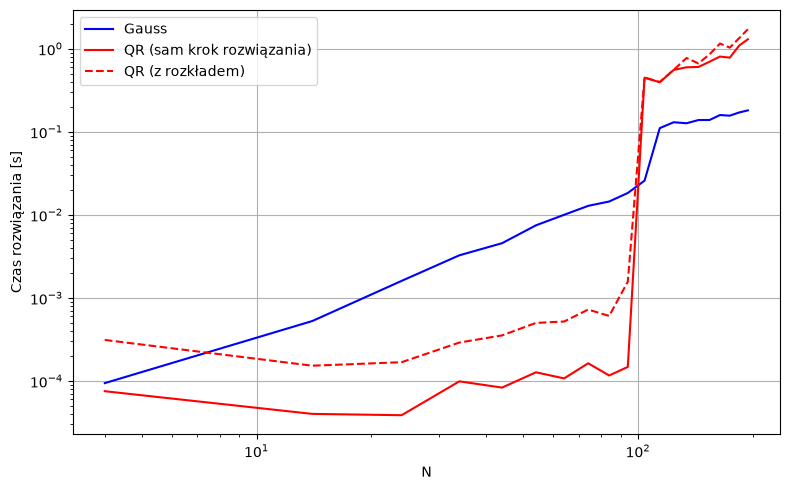

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.random.seed(42)
Nmax = 200
step = 10

zlozonoscGauss = []; zlozonoscQR = []; zlozonoscQRFull = []
sizes = []

print("Rozwiązywanie... (to może trwać ~30s)")
T0 = time.perf_counter()
for i in range(4, Nmax + 1, step):
    A = np.random.rand(i, i).astype(np.float64)
    b = A.sum(axis=1).astype(np.float64)
    gauss_all, gauss_simple, gauss_err = solveUsingGaussElimination(A, b)
    zlozonoscGauss.append(gauss_all)
    sizes.append(i)
    qr_all, qr_simple, qr_err = solveUsingQRFactorization(A, b)
    zlozonoscQR.append(qr_simple)
    zlozonoscQRFull.append(qr_all)
    if i % 10 == 0:
        elapsed = time.perf_counter() - T0
        print(f"  N={i:4d}/{Nmax}  ({elapsed:.1f}s)")

print(f"Gotowe! Całkowity czas: {time.perf_counter()-T0:.1f}s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(sizes, zlozonoscGauss, 'b', label='Gauss')
ax.plot(sizes, zlozonoscQR, 'r', label='QR (sam krok rozwiązania)')
ax.plot(sizes, zlozonoscQRFull, 'r--', label='QR (z rozkładem)')
ax.set_xlabel('N')
ax.set_ylabel('Czas rozwiązania [s]')
ax.grid(True)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()